In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [4]:
df = pd.read_csv("../data/raw/credit_risk_dataset.csv")

df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [5]:
df.shape

(32581, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [7]:
df.isna().sum().sort_values(ascending=False)

loan_int_rate                 3116
person_emp_length              895
person_age                       0
person_income                    0
person_home_ownership            0
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,32581.0,27.734600,6.348078,20.00,23.00,26.00,30.00,144.00
person_income,32581.0,66074.848470,61983.119168,4000.00,38500.00,55000.00,79200.00,6000000.00
person_emp_length,31686.0,4.789686,4.142630,0.00,2.00,4.00,7.00,123.00
loan_amnt,32581.0,9589.371106,6322.086646,500.00,5000.00,8000.00,12200.00,35000.00
loan_int_rate,29465.0,11.011695,3.240459,5.42,7.90,10.99,13.47,23.22
loan_status,32581.0,0.218164,0.413006,0.00,0.00,0.00,0.00,1.00
loan_percent_income,32581.0,0.170203,0.106782,0.00,0.09,0.15,0.23,0.83
cb_person_cred_hist_length,32581.0,5.804211,4.055001,2.00,3.00,4.00,8.00,30.00


In [9]:
df.isna().sum().sort_values(ascending=False)

loan_int_rate                 3116
person_emp_length              895
person_age                       0
person_income                    0
person_home_ownership            0
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

## Entendimento inicial dos dados

Nesta etapa, vou verificar o tamanho da base, os tipos das colunas, valores ausentes e estatísticas iniciais.

A base traz informações de perfil do cliente, renda, moradia, tempo de emprego, características do empréstimo e status de inadimplência.

In [10]:
df["loan_status"].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

In [11]:
df["loan_status"].value_counts(normalize=True).round(4)

loan_status
0    0.7818
1    0.2182
Name: proportion, dtype: float64

In [12]:
df["loan_status"].value_counts(normalize=True).mul(100).round(2)

loan_status
0    78.18
1    21.82
Name: proportion, dtype: float64

In [13]:
df["loan_intent"].value_counts()

loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64

In [14]:
df["loan_grade"].value_counts().sort_index()

loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64

In [15]:
df["person_home_ownership"].value_counts()

person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64

In [16]:
df.isna().sum().sort_values(ascending=False)

loan_int_rate                 3116
person_emp_length              895
person_age                       0
person_income                    0
person_home_ownership            0
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

### Leitura inicial da inadimplência

A base apresenta uma taxa de inadimplência de 21,82%. Isso significa que aproximadamente 1 em cada 5 empréstimos da amostra está marcado como inadimplente.

Esse percentual será usado como referência para comparar o risco entre diferentes grupos, como finalidade do empréstimo, grade de crédito, renda, idade e comprometimento da renda.

In [17]:
default_rate = (
    df["loan_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename(index={0: "Adimplente", 1: "Inadimplente"})
)

default_rate

loan_status
Adimplente      78.18
Inadimplente    21.82
Name: proportion, dtype: float64

## Limpeza inicial

A base possui valores ausentes em duas colunas: `loan_int_rate` e `person_emp_length`.

Como essas variáveis são importantes para a análise e os valores ausentes não representam a maior parte da base, optei por preencher os nulos com a mediana de cada coluna.

In [18]:
df_clean = df.copy()

df_clean.shape

(32581, 12)

In [19]:
df_clean["loan_int_rate"] = df_clean["loan_int_rate"].fillna(df_clean["loan_int_rate"].median())
df_clean["person_emp_length"] = df_clean["person_emp_length"].fillna(df_clean["person_emp_length"].median())

df_clean.isna().sum().sort_values(ascending=False)

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

## Criação de variáveis

Para facilitar a análise, criei algumas variáveis auxiliares relacionadas à inadimplência, faixa etária, faixa de renda e comprometimento da renda com o empréstimo.

In [20]:
df_clean["default_status"] = df_clean["loan_status"].map({
    0: "Adimplente",
    1: "Inadimplente"
})

df_clean["age_group"] = pd.cut(
    df_clean["person_age"],
    bins=[0, 25, 35, 45, 60, 100],
    labels=["Até 25", "26-35", "36-45", "46-60", "60+"]
)

df_clean["income_group"] = pd.qcut(
    df_clean["person_income"],
    q=4,
    labels=["Baixa renda", "Média-baixa", "Média-alta", "Alta renda"]
)

df_clean["loan_income_group"] = pd.cut(
    df_clean["loan_percent_income"],
    bins=[0, 0.10, 0.20, 0.30, 1],
    labels=["Até 10%", "10%-20%", "20%-30%", "Acima de 30%"]
)

df_clean[[
    "person_age",
    "person_income",
    "loan_amnt",
    "loan_percent_income",
    "default_status",
    "age_group",
    "income_group",
    "loan_income_group"
]].head()

,person_age,person_income,loan_amnt,loan_percent_income,default_status,age_group,income_group,loan_income_group
0,22,59000,35000,0.59,Inadimplente,Até 25,Média-alta,Acima de 30%
1,21,9600,1000,0.10,Adimplente,Até 25,Baixa renda,Até 10%
2,25,9600,5500,0.57,Inadimplente,Até 25,Baixa renda,Acima de 30%
3,23,65500,35000,0.53,Inadimplente,Até 25,Média-alta,Acima de 30%
4,24,54400,35000,0.55,Inadimplente,Até 25,Média-baixa,Acima de 30%


In [19]:
overall_default_rate = df_clean["loan_status"].mean() * 100

print(f"Taxa geral de inadimplência: {overall_default_rate:.2f}%")

Taxa geral de inadimplência: 21.82%


## Análise da inadimplência por grupos

Nesta etapa, vou comparar a taxa de inadimplência entre diferentes grupos da base, como finalidade do empréstimo, grade de crédito, faixa de renda, faixa etária e comprometimento da renda.

In [21]:
def default_rate_by_group(data, group_col):
    summary = (
        data
        .groupby(group_col, observed=False)
        .agg(
            customers=("loan_status", "count"),
            default_rate=("loan_status", "mean"),
            avg_income=("person_income", "mean"),
            avg_loan_amount=("loan_amnt", "mean"),
            avg_interest_rate=("loan_int_rate", "mean")
        )
        .reset_index()
    )

    summary["default_rate"] = summary["default_rate"] * 100

    return summary.round(2)

In [28]:
default_by_intent = default_rate_by_group(df_clean, "loan_intent")
default_by_intent.sort_values("default_rate", ascending=False)

,loan_intent,customers,default_rate,avg_income,avg_loan_amount,avg_interest_rate
0,DEBTCONSOLIDATION,5212,28.59,66470.88,9594.89,10.98
3,MEDICAL,6071,26.70,61437.23,9259.58,11.05
2,HOMEIMPROVEMENT,3605,26.10,73549.47,10360.52,11.18
4,PERSONAL,5521,19.89,67864.14,9573.77,11.00
1,EDUCATION,6453,17.22,64135.20,9482.68,10.95
5,VENTURE,5719,14.81,66386.57,9583.78,10.95


In [29]:
default_by_grade = default_rate_by_group(df_clean, "loan_grade")
default_by_grade.sort_values("loan_grade")

,loan_grade,customers,default_rate,avg_income,avg_loan_amount,avg_interest_rate
0,A,10777,9.96,66568.21,8539.27,7.67
1,B,10451,16.28,66354.84,9995.48,10.99
2,C,6458,20.73,64921.94,9213.86,13.22
3,D,3626,59.05,63663.68,10849.24,14.99
4,E,964,64.42,70873.11,12915.85,16.49
5,F,241,70.54,77008.73,14717.32,17.76
6,G,64,98.44,76773.30,17195.70,19.53


In [30]:
default_by_income = default_rate_by_group(df_clean, "income_group")
default_by_income.sort_values("default_rate", ascending=False)

,income_group,customers,default_rate,avg_income,avg_loan_amount,avg_interest_rate
0,Baixa renda,8152,39.70,28615.32,6308.23,11.20
1,Média-baixa,8231,21.32,47041.93,8499.61,10.97
2,Média-alta,8055,17.07,66282.42,10453.44,10.94
3,Alta renda,8143,9.11,122609.04,13120.94,10.93


In [31]:
default_by_age = default_rate_by_group(df_clean, "age_group")
default_by_age.sort_values("default_rate", ascending=False)

,age_group,customers,default_rate,avg_income,avg_loan_amount,avg_interest_rate
4,60+,65,26.15,98879.89,12436.54,11.15
0,Até 25,15352,23.03,58958.47,9208.81,10.97
3,46-60,582,21.82,84029.88,9768.04,11.01
2,36-45,2814,20.72,77093.39,9978.89,11.16
1,26-35,13763,20.68,70389.65,9912.62,11.02


In [32]:
default_by_loan_income = default_rate_by_group(df_clean, "loan_income_group")
default_by_loan_income.sort_values("default_rate", ascending=False)

,loan_income_group,customers,default_rate,avg_income,avg_loan_amount,avg_interest_rate
3,Acima de 30%,3834,70.32,41620.22,15786.38,11.60
2,20%-30%,6197,21.95,52311.52,12978.86,11.48
1,10%-20%,12066,15.11,64409.38,9646.93,10.93
0,Até 10%,10475,11.73,83663.28,5254.53,10.60


In [46]:
from pathlib import Path

Path("../outputs/tables").mkdir(parents=True, exist_ok=True)

default_by_intent.to_csv("../outputs/tables/default_by_intent.csv", index=False)
default_by_grade.to_csv("../outputs/tables/default_by_grade.csv", index=False)
default_by_income.to_csv("../outputs/tables/default_by_income.csv", index=False)
default_by_age.to_csv("../outputs/tables/default_by_age.csv", index=False)
default_by_loan_income.to_csv("../outputs/tables/default_by_loan_income.csv", index=False)

print("Tabelas salvas com sucesso.")

Tabelas salvas com sucesso.


### Principais leituras da análise por grupos

A inadimplência varia bastante entre os grupos analisados.

Por finalidade do empréstimo, os maiores percentuais aparecem em `DEBTCONSOLIDATION`, `MEDICAL` e `HOMEIMPROVEMENT`. Isso pode indicar maior risco em empréstimos ligados a reorganização de dívidas, despesas médicas ou gastos não recorrentes.

A grade de crédito mostra uma diferença bem clara: clientes nas grades A, B e C têm inadimplência menor, enquanto as grades D, E, F e G apresentam risco muito mais alto. A grade G tem a maior taxa observada.

A faixa de renda também mostra um padrão importante. Clientes de baixa renda têm inadimplência bem superior aos clientes de alta renda.

O comprometimento da renda com o empréstimo é um dos sinais mais fortes da análise. Clientes com empréstimos acima de 30% da renda apresentam inadimplência muito maior do que os demais grupos.

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/raw/credit_risk_dataset.csv")

df_clean = df.copy()

df_clean["loan_int_rate"] = df_clean["loan_int_rate"].fillna(df_clean["loan_int_rate"].median())
df_clean["person_emp_length"] = df_clean["person_emp_length"].fillna(df_clean["person_emp_length"].median())

df_clean["default_status"] = df_clean["loan_status"].map({
    0: "Adimplente",
    1: "Inadimplente"
})

df_clean["age_group"] = pd.cut(
    df_clean["person_age"],
    bins=[0, 25, 35, 45, 60, 100],
    labels=["Até 25", "26-35", "36-45", "46-60", "60+"]
)

df_clean["income_group"] = pd.qcut(
    df_clean["person_income"],
    q=4,
    labels=["Baixa renda", "Média-baixa", "Média-alta", "Alta renda"]
)

df_clean["loan_income_group"] = pd.cut(
    df_clean["loan_percent_income"],
    bins=[0, 0.10, 0.20, 0.30, 1],
    labels=["Até 10%", "10%-20%", "20%-30%", "Acima de 30%"]
)

def default_rate_by_group(data, group_col):
    summary = (
        data
        .groupby(group_col, observed=False)
        .agg(
            customers=("loan_status", "count"),
            default_rate=("loan_status", "mean"),
            avg_income=("person_income", "mean"),
            avg_loan_amount=("loan_amnt", "mean"),
            avg_interest_rate=("loan_int_rate", "mean")
        )
        .reset_index()
    )

    summary["default_rate"] = summary["default_rate"] * 100

    return summary.round(2)

default_by_intent = default_rate_by_group(df_clean, "loan_intent")
default_by_grade = default_rate_by_group(df_clean, "loan_grade")
default_by_income = default_rate_by_group(df_clean, "income_group")
default_by_age = default_rate_by_group(df_clean, "age_group")
default_by_loan_income = default_rate_by_group(df_clean, "loan_income_group")

def add_percent_labels(ax):
    for p in ax.patches:
        if p.get_width() > p.get_height():
            value = p.get_width()
            ax.annotate(
                f"{value:.2f}%",
                (p.get_width(), p.get_y() + p.get_height() / 2),
                xytext=(5, 0),
                textcoords="offset points",
                ha="left",
                va="center"
            )
        else:
            value = p.get_height()
            ax.annotate(
                f"{value:.2f}%",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                xytext=(0, 5),
                textcoords="offset points",
                ha="center",
                va="bottom"
            )

In [57]:
def add_labels(ax, fmt="{:.2f}%"):
    for p in ax.patches:
        value = p.get_width() if p.get_width() > 0 else p.get_height()

        if p.get_width() > p.get_height():
            ax.annotate(
                fmt.format(value),
                (p.get_width(), p.get_y() + p.get_height() / 2),
                xytext=(5, 0),
                textcoords="offset points",
                ha="left",
                va="center"
            )
        else:
            ax.annotate(
                fmt.format(value),
                (p.get_x() + p.get_width() / 2, p.get_height()),
                xytext=(0, 5),
                textcoords="offset points",
                ha="center",
                va="bottom"
            )

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

def add_percent_labels(ax):
    for p in ax.patches:
        if p.get_width() > p.get_height():
            value = p.get_width()
            ax.annotate(
                f"{value:.2f}%",
                (p.get_width(), p.get_y() + p.get_height() / 2),
                xytext=(5, 0),
                textcoords="offset points",
                ha="left",
                va="center"
            )
        else:
            value = p.get_height()
            ax.annotate(
                f"{value:.2f}%",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                xytext=(0, 5),
                textcoords="offset points",
                ha="center",
                va="bottom"
            )

In [59]:
sns.set_theme(style="whitegrid")

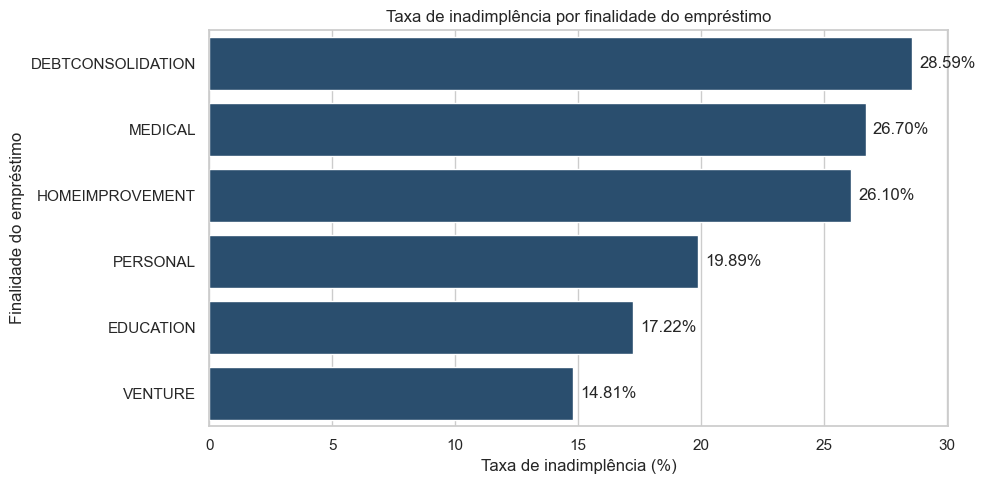

In [60]:
default_by_intent_plot = default_by_intent.sort_values("default_rate", ascending=False)

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=default_by_intent_plot,
    x="default_rate",
    y="loan_intent",
    color="#1F4E79"
)

plt.title("Taxa de inadimplência por finalidade do empréstimo")
plt.xlabel("Taxa de inadimplência (%)")
plt.ylabel("Finalidade do empréstimo")

add_percent_labels(ax)

plt.tight_layout()
plt.savefig("../outputs/charts/default_rate_by_intent.png")
plt.show()

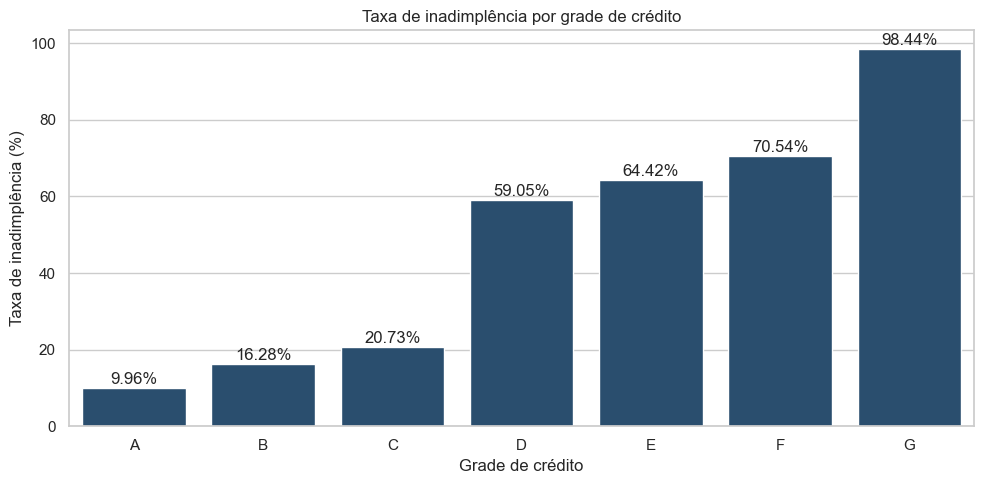

In [61]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=default_by_grade_plot,
    x="loan_grade",
    y="default_rate",
    color="#1F4E79"
)

plt.title("Taxa de inadimplência por grade de crédito")
plt.xlabel("Grade de crédito")
plt.ylabel("Taxa de inadimplência (%)")

for index, row in default_by_grade_plot.iterrows():
    plt.text(
        x=index,
        y=row["default_rate"] + 1,
        s=f'{row["default_rate"]:.2f}%',
        ha="center"
    )

plt.tight_layout()
plt.savefig("../outputs/charts/default_rate_by_grade.png")
plt.show()

c:\Users\gabri\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


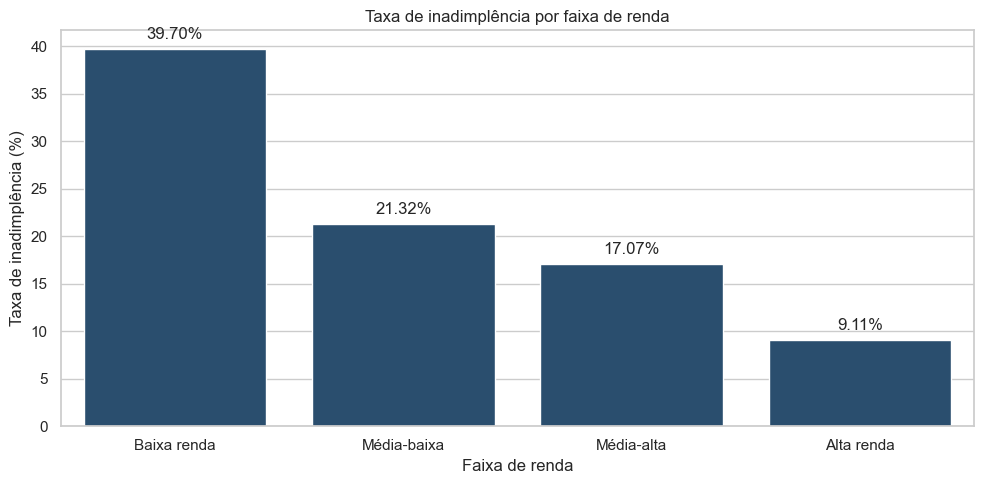

In [62]:
income_order = ["Baixa renda", "Média-baixa", "Média-alta", "Alta renda"]

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=default_by_income,
    x="income_group",
    y="default_rate",
    order=income_order,
    color="#1F4E79"
)

plt.title("Taxa de inadimplência por faixa de renda")
plt.xlabel("Faixa de renda")
plt.ylabel("Taxa de inadimplência (%)")

add_percent_labels(ax)

plt.tight_layout()
plt.savefig("../outputs/charts/default_rate_by_income_group.png")
plt.show()

c:\Users\gabri\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


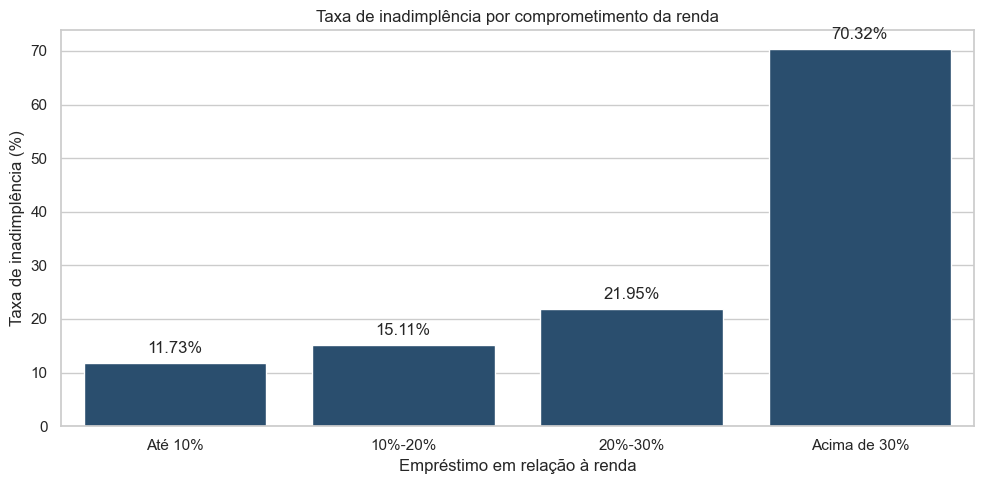

In [63]:
loan_income_order = ["Até 10%", "10%-20%", "20%-30%", "Acima de 30%"]

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=default_by_loan_income,
    x="loan_income_group",
    y="default_rate",
    order=loan_income_order,
    color="#1F4E79"
)

plt.title("Taxa de inadimplência por comprometimento da renda")
plt.xlabel("Empréstimo em relação à renda")
plt.ylabel("Taxa de inadimplência (%)")

add_percent_labels(ax)

plt.tight_layout()
plt.savefig("../outputs/charts/default_rate_by_loan_income_group.png")
plt.show()

c:\Users\gabri\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


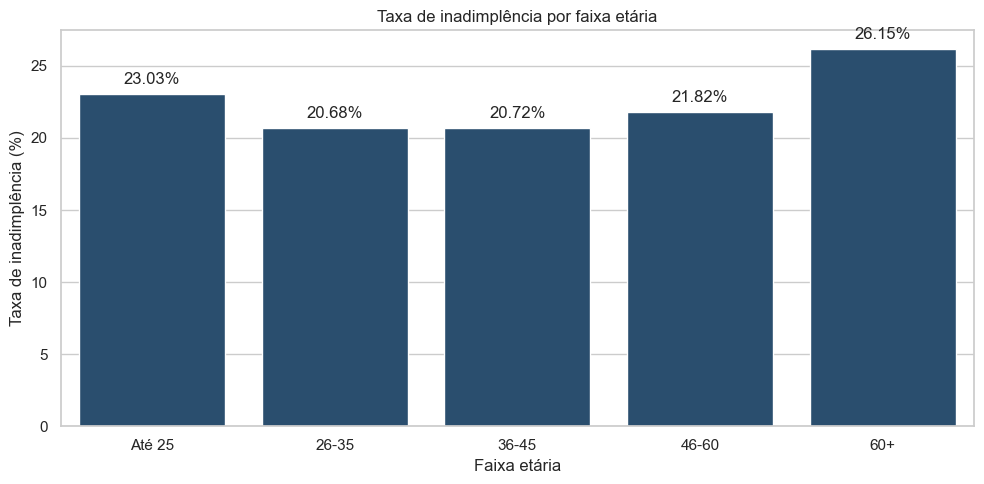

In [54]:
age_order = ["Até 25", "26-35", "36-45", "46-60", "60+"]

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=default_by_age,
    x="age_group",
    y="default_rate",
    order=age_order,
    color="#1F4E79"
)

plt.title("Taxa de inadimplência por faixa etária")
plt.xlabel("Faixa etária")
plt.ylabel("Taxa de inadimplência (%)")

add_percent_labels(ax)

plt.tight_layout()
plt.savefig("../outputs/charts/default_rate_by_age_group.png")
plt.show()

In [30]:
Path("../data/processed").mkdir(parents=True, exist_ok=True)

df_clean.to_csv("../data/processed/credit_risk_clean.csv", index=False)

print("Base tratada salva com sucesso.")

Base tratada salva com sucesso.


## Conclusões

A análise mostrou que a taxa geral de inadimplência da base é de 21,82%.

Alguns fatores parecem estar mais associados ao risco de crédito:

- Clientes com maior comprometimento da renda apresentam inadimplência mais alta.
- Grades de crédito piores concentram taxas de inadimplência muito maiores.
- Clientes de baixa renda têm inadimplência superior aos demais grupos.
- Empréstimos para `DEBTCONSOLIDATION`, `MEDICAL` e `HOMEIMPROVEMENT` apresentaram maiores taxas de inadimplência.

O comprometimento da renda se destacou como um dos principais sinais de risco. Clientes com empréstimos acima de 30% da renda tiveram inadimplência bem acima dos demais grupos.

## Possíveis próximos passos

- Criar uma classificação simples de risco por regras.
- Comparar inadimplência por combinação de renda e grade de crédito.
- Avaliar a relação entre taxa de juros e inadimplência.
- Criar um dashboard com os principais indicadores de risco.